In [25]:
# usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics, svm

# use KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# let's add some helpful features like the pipelines
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

<h2>Data Set Link:</h2>

  <a href="https://www.kaggle.com/datasets/buddhadebsarkar/customer-purchase-prediction">
    Customer Purchase Prediction Dataset
  </a>



<h3>STEP 1 - Load the data & Cleaning the dataset</h3>

In [26]:
# load the data
df = pd.read_csv("purchase_prediction.csv")

# let's quickly see the first 5 rows of data
df

,Customer_Age,Income,Marital_Status,Education_Level,Number_of_Children,Shopping_History_Score,Product_Category_Interest,Discount_Offered,Purchased
0,57,74292,Married,PhD,0,56,Sports,26,Yes
1,68,23851,Married,PhD,3,93,Sports,40,No
2,47,71396,Single,PhD,1,95,Electronics,32,Yes
3,45,77218,Single,Bachelor,3,80,Fashion,38,Yes
4,33,23443,Single,PhD,5,83,Home Decor,8,No
...,...,...,...,...,...,...,...,...,...
995,35,48707,Single,PhD,3,60,Fashion,28,No
996,20,29063,Divorced,PhD,0,36,Home Decor,42,Yes
997,58,77691,Married,Master,3,37,Sports,40,No
998,69,27282,Divorced,Master,2,79,Electronics,49,No


In [27]:
# check duplicates 
df.duplicated().sum()

np.int64(0)

In [28]:
# how many rows in total do we have?
len(df)

1000

In [29]:
# missing values per column
df.isna().sum()

Customer_Age                 0
Income                       0
Marital_Status               0
Education_Level              0
Number_of_Children           0
Shopping_History_Score       0
Product_Category_Interest    0
Discount_Offered             0
Purchased                    0
dtype: int64

In [30]:
# Check value counts for Marital_Status
df['Marital_Status'].value_counts()

Marital_Status
Divorced    338
Single      337
Married     325
Name: count, dtype: int64

In [31]:
# Check value counts for Education_Level
df['Education_Level'].value_counts()

Education_Level
Bachelor       267
PhD            250
Master         244
High School    239
Name: count, dtype: int64

In [32]:
# Map Smoking_Status - Ordinal categories
category_mapper = {
    'PhD': 3,
    'Master': 2,
    'Bachelor': 1,
    'High School': 0
}

df['Education_Level'] = df['Education_Level'].replace(category_mapper)
df.head()

,Customer_Age,Income,Marital_Status,Education_Level,Number_of_Children,Shopping_History_Score,Product_Category_Interest,Discount_Offered,Purchased
0,57,74292,Married,3,0,56,Sports,26,Yes
1,68,23851,Married,3,3,93,Sports,40,No
2,47,71396,Single,3,1,95,Electronics,32,Yes
3,45,77218,Single,1,3,80,Fashion,38,Yes
4,33,23443,Single,3,5,83,Home Decor,8,No


In [33]:
# Check value counts for Product_Category_Interest
df['Product_Category_Interest'].value_counts()

Product_Category_Interest
Electronics    265
Home Decor     260
Sports         248
Fashion        227
Name: count, dtype: int64

In [34]:
# this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ['Marital_Status','Product_Category_Interest']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

df.head()

,Customer_Age,Income,Education_Level,Number_of_Children,Shopping_History_Score,Discount_Offered,Purchased,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Product_Category_Interest_Electronics,Product_Category_Interest_Fashion,Product_Category_Interest_Home Decor,Product_Category_Interest_Sports
0,57,74292,3,0,56,26,Yes,0,1,0,0,0,0,1
1,68,23851,3,3,93,40,No,0,1,0,0,0,0,1
2,47,71396,3,1,95,32,Yes,0,0,1,1,0,0,0
3,45,77218,1,3,80,38,Yes,0,0,1,0,1,0,0
4,33,23443,3,5,83,8,No,0,0,1,0,0,1,0


In [ ]:
# Check value counts for Purchased
df['Purchased'].value_counts()

Purchased
No     680
Yes    320
Name: count, dtype: int64

In [36]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ['Purchased']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

<h3>There's no ordinal or nominal categories here, we can proceed to X/y -phase</h3>

In [37]:
df.head()

,Customer_Age,Income,Education_Level,Number_of_Children,Shopping_History_Score,Discount_Offered,Purchased,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Product_Category_Interest_Electronics,Product_Category_Interest_Fashion,Product_Category_Interest_Home Decor,Product_Category_Interest_Sports
0,57,74292,3,0,56,26,1,0,1,0,0,0,0,1
1,68,23851,3,3,93,40,0,0,1,0,0,0,0,1
2,47,71396,3,1,95,32,1,0,0,1,1,0,0,0
3,45,77218,1,3,80,38,1,0,0,1,0,1,0,0
4,33,23443,3,5,83,8,0,0,0,1,0,0,1,0


<h3>X/y and train/test -splits</h3>

In [38]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Purchased", axis=1)

# our target variable is y
y = df['Purchased']

In [39]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Based on iterations, best k-value is this:
15


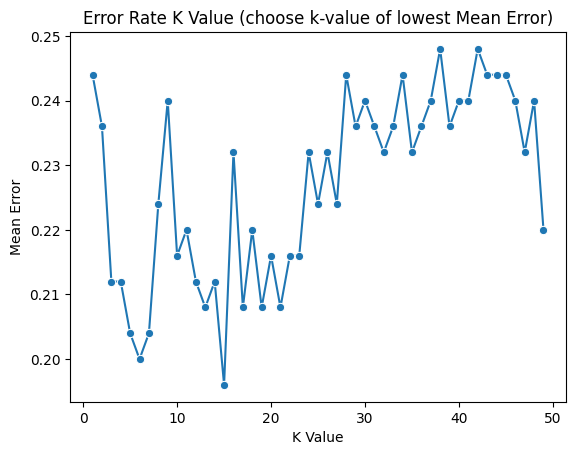

In [40]:
# CLASSIFIER VERSION
# adjust this to 50 or even 150 if you have lots of data rows
max_iterations = 50

# list to save the error values in the loop
error = []

# the default metric in scikit-learn
metric_selection = "minkowski"

# Calculating error for K values between 1 and 40
for i in range(1, max_iterations):

     # try with current k-value, train the model and make a test prediction
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=i, metric=metric_selection))
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)

    # save the error value for this k-value
    error.append(np.mean(pred_i != y_test))
    
# plot all the k-values and their error values
sns.lineplot(x=range(1, max_iterations), y=error, marker='o')
plt.title('Error Rate K Value (choose k-value of lowest Mean Error)')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

# choose best k-value based on metrics
# we have to add +1 to k-value, since argmin() returns an index
# which starts from 0, but k-values start from 1
print("Based on iterations, best k-value is this:")
k_value = np.argmin(error) + 1
print(k_value)

Train the logistic regression model

In [41]:
# create the model and train it with the data
# model = LogisticRegression()
# use probability=True for easier metrics

# if you wish to use LinearSVC => we need to wrap it into a
# CalibratedClassifierCV so it outputs probabilities for the metrics
# model = make_pipeline(StandardScaler(), CalibratedClassifierCV(svm.LinearSVC()))

# Pipeline is super helpful here, since we can integrate the scaler
# before the model, no need to manually scale anything
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_value, metric=metric_selection))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(15)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depen

Classification error metrics

In [42]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

In [43]:
# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87       176
           1       0.75      0.51      0.61        74

    accuracy                           0.80       250
   macro avg       0.78      0.72      0.74       250
weighted avg       0.80      0.80      0.79       250


Model overall accuracy: 80.40%


<Axes: >

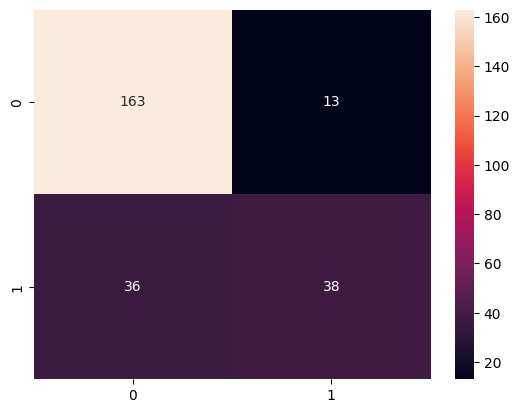

In [44]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

In [45]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.8533092751842752

In [46]:
df.columns

Index(['Customer_Age', 'Income', 'Education_Level', 'Number_of_Children',
       'Shopping_History_Score', 'Discount_Offered', 'Purchased',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Product_Category_Interest_Electronics',
       'Product_Category_Interest_Fashion',
       'Product_Category_Interest_Home Decor',
       'Product_Category_Interest_Sports'],
      dtype='str')

In [47]:
# Map all variables into a Python dictionary
tester_row = {
    'Customer_Age': 35,
    'Income': 50000,
    'Education_Level': 2,
    'Number_of_Children': 1,
    'Shopping_History_Score': 75,
    'Discount_Offered': 10,

    'Marital_Status_Divorced': 0,
    'Marital_Status_Married': 1,
    'Marital_Status_Single': 0,

    'Product_Category_Interest_Electronics': 1,
    'Product_Category_Interest_Fashion': 0,
    'Product_Category_Interest_Home Decor': 0,
    'Product_Category_Interest_Sports': 0
}

# Convert to pandas DataFrame
tester_row = pd.DataFrame([tester_row])



In [48]:
print("All probabilities by category:")
print(model.predict_proba(tester_row))
print()

# change these based on your original data
labels = ["No", "Yes"]

print("Did this customer buy the service (Yes/No):")
result = labels[model.predict(tester_row)[0]]
print(result)
print("-------------------")

All probabilities by category:
[[0.73333333 0.26666667]]

Did this customer buy the service (Yes/No):
No
-------------------


<h2 style="color: blue;">My thoughts</h2>
<p> Best K Value = 15 <br/>

<h5>Classification Report — 80.40% Accuracy </h5> </p>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th>Class</th>
    <th>Precision</th>
    <th>Recall</th>
    <th>F1-Score</th>
    <th>Meaning</th>
  </tr>

  <tr>
    <td>0 (No Purchase)</td>
    <td>0.82</td>
    <td>0.93</td>
    <td>0.87</td>
    <td>Model is very good at identifying non-buyers</td>
  </tr>

  <tr>
    <td>1 (Purchase)</td>
    <td>0.75</td>
    <td>0.51</td>
    <td>0.61</td>
    <td>Model struggles to catch actual buyers</td>
  </tr>
</table>

<p>The imbalance is clear:

<ul>
<li>Class 0 has 176 samples → model learned it well</li>
<li>Class 1 has only 74 samples → model misses many buyers</li>


<h5>Confusion Matrix</h5>

<table border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th></th>
    <th>Predicted 0</th>
    <th>Predicted 1</th>
  </tr>

  <tr>
    <th>Actual 0</th>
    <td>163</td>
    <td>13</td>
  </tr>

  <tr>
    <th>Actual 1</th>
    <td>36</td>
    <td>38</td>
  </tr>
</table>

<p>
  Only 13 false alarms were made, but the model missed 36 actual buyers.
</p>
<ul>
  <li>163 correct — correctly said "won't buy" ✅</li>
  <li>38 correct — correctly said "will buy" ✅</li>
  <li>13 false positives — predicted buy, but didn't ❌</li>
  <li>36 false negatives — predicted no buy, but they did ❌ --> biggest problem</li>
</ul>

<h5>ROC-AUC = 0.853 → Good and model accuracy is 80.40% </h5> 





